### Stage 0: Environment Setup & Configuration


In [ ]:
# pip install tensorflow pydicom opencv-python pandas scikit-learn matplotlib gudhi scipy
from __future__ import annotations
import os, random, json, gc
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Tuple, List, Optional, Any

import cv2
import numpy as np
import pandas as pd
import pydicom
import scipy.stats
import matplotlib.pyplot as plt
import gudhi
from gudhi.representations import PersistenceImage

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score, 
    recall_score, brier_score_loss
)

import tensorflow as tf
from tensorflow.keras import layers, models, applications, callbacks, optimizers, regularizers

# Hardware Configuration
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(f"Memory growth setting warning: {e}")
    print(f"GPU Acceleration Active: {[g.name for g in gpus]}")
else:
    print("No GPU detected. Running on CPU.")

@dataclass(frozen=True)
class Config:
    """Configuration parameters for data processing, model training, and evaluation."""
    data_root: Path = Path('cbis_ddsm')
    train_csv: Path = Path('calc_case_description_train_set.csv')
    test_csv: Path = Path('calc_case_description_test_set.csv')
    output_root: Path = Path('CBISDDSM_Preprocessed_v2')
    image_height: int = 224
    image_width: int = 224
    tda_dim: int = 800                   # Concatenation of two 400-d vectors (H0 and H1)
    validation_fraction: float = 0.15     # Validation partition size
    seeds: Tuple[int, ...] = (42, 123, 2026)  # Evaluation seeds
    batch_size: int = 16
    stage1_epochs: int = 15              # Warmup epochs for classification head
    stage2_epochs: int = 30              # Fine tuning epochs
    stage1_lr: float = 1e-4              # Head learning rate
    stage2_lr: float = 1e-5              # Backbone fine tuning learning rate
    active_bw: float = 0.1               # Gaussian kernel bandwidth for persistence images
    use_clahe: bool = True               # Contrast enhancement flag

CFG = Config()

def set_seed(seed: int) -> None:
    """Set random seeds across Python, NumPy, and TensorFlow."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

set_seed(CFG.seeds[0])
print(f"Environment initialized. Configured evaluation seeds: {CFG.seeds}")


I0000 00:00:1790551169.360086   68657 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790551169.663326   68657 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790551171.367299   68657 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU Acceleration Active: ['/physical_device:GPU:0']
Environment initialized. Configured evaluation seeds: (42, 123, 2026)


### Stage 1: Data Manifest Verification & Topological Feature Extraction


In [ ]:
# Manifest verification and persistence image extraction
manifest_dir = CFG.output_root / 'manifests'
manifest_dir.mkdir(parents=True, exist_ok=True)
proc_file = manifest_dir / 'processed.csv'
tda_feat_file = manifest_dir / 'tda_normalized.pkl'

assert proc_file.exists(), f"Processed manifest not found at {proc_file}. Run baseline preprocessing first."

proc_df = pd.read_csv(proc_file)
print(f"Loaded processed dataset: {len(proc_df)} cases ({(proc_df.split=='train').sum()} train, {(proc_df.split=='test').sum()} test)")

if tda_feat_file.exists():
    tda_normalized_df = pd.read_pickle(tda_feat_file)
    print(f"Loaded cached TDA feature vectors ({len(tda_normalized_df)} samples).")
else:
    print(f"Computing persistence images from cubical complexes (bandwidth={CFG.active_bw})...")
    pi_h0 = PersistenceImage(bandwidth=CFG.active_bw, weight=lambda x: x[1], resolution=[20, 20], im_range=[0, 1, 0, 1])
    pi_h1 = PersistenceImage(bandwidth=CFG.active_bw, weight=lambda x: x[1], resolution=[20, 20], im_range=[0, 1, 0, 1])
    
    # 1. Accumulate all diagrams first
    h0_list, h1_list = [], []
    valid_indices = []
    
    for idx, r in proc_df.iterrows():
        img = cv2.imread(r.image_png, cv2.IMREAD_GRAYSCALE)
        if img is None:
            h0_list.append(np.empty((0, 2)))
            h1_list.append(np.empty((0, 2)))
            continue
            
        cc = gudhi.CubicalComplex(top_dimensional_cells=img.astype(np.float64))
        cc.compute_persistence()
        
        h0 = cc.persistence_intervals_in_dimension(0)
        h1 = cc.persistence_intervals_in_dimension(1)
        if len(h0) > 0: h0[np.isinf(h0)] = 255.0
        if len(h1) > 0: h1[np.isinf(h1)] = 255.0        
        
        # Rescale birth/death pairs to [0, 1] relative to 8 bit dynamic range
        h0_list.append(h0 / 255.0 if len(h0) else np.empty((0, 2)))
        h1_list.append(h1 / 255.0 if len(h1) else np.empty((0, 2)))

    # 2. Generate vector representations independently for H0 and H1
    p0_features = pi_h0.fit_transform(h0_list)
    p1_features = pi_h1.fit_transform(h1_list)
    
    # 3. Concatenate and save
    mat = np.concatenate([p0_features, p1_features], axis=1).astype(np.float32)
    tda_normalized_df = pd.DataFrame({'sample_uid': proc_df['sample_uid'], 'split': proc_df['split'], 'tda_norm': list(mat)})
    tda_normalized_df.to_pickle(tda_feat_file)
    print(f"Extracted TDA representations: feature matrix shape {mat.shape}")
    
mat_check = np.vstack(tda_normalized_df['tda_norm'].values)
active_pct = (mat_check > 1e-5).sum(axis=1).mean() / CFG.tda_dim * 100
print(f"TDA feature density: {(mat_check > 1e-5).sum(axis=1).mean():.1f}/{CFG.tda_dim} non-zero entries on average ({active_pct:.1f}%)")


Loaded processed dataset: 1045 cases (856 train, 189 test)
Loaded cached TDA feature vectors (1045 samples).
TDA feature density: 655.1/800 non-zero entries on average (81.9%)


### Stage 2: Patient-Stratified Splitting & Input Pipeline


In [3]:
def get_master_df_for_seed(seed: int, base_df: pd.DataFrame = proc_df) -> pd.DataFrame:
    """Partition dataset into train and validation sets stratified at the patient level."""
    cands_df = base_df[base_df.split != 'test'].copy()
    test_df = base_df[base_df.split == 'test'].copy()
    
    patient_labels = cands_df.groupby('patient_id', as_index=False).label.max()
    train_pats, val_pats = train_test_split(
        patient_labels.patient_id, 
        test_size=CFG.validation_fraction, 
        stratify=patient_labels.label, 
        random_state=seed
    )
    
    train_manifest = cands_df[cands_df.patient_id.isin(train_pats)].copy(); train_manifest['split'] = 'train'
    val_manifest = cands_df[cands_df.patient_id.isin(val_pats)].copy(); val_manifest['split'] = 'val'
    return pd.concat([train_manifest, val_manifest, test_df], ignore_index=True)

def scale_tda_for_seed(master_seed_df: pd.DataFrame, tda_df: pd.DataFrame) -> pd.DataFrame:
    """Fit StandardScaler on the training split only and apply to all splits."""
    merged = master_seed_df[['sample_uid', 'split']].merge(tda_df[['sample_uid', 'tda_norm']], on='sample_uid')
    X_all = np.vstack(merged['tda_norm'].values)
    
    train_mask = (merged['split'] == 'train').values
    scaler = StandardScaler().fit(X_all[train_mask])
    scaler.scale_ = np.where(scaler.scale_ < 1e-4, 1.0, scaler.scale_)
    
    X_scaled = np.clip(scaler.transform(X_all), -10.0, 10.0).astype(np.float32)
    tda_scaled_df = pd.DataFrame(X_scaled, columns=[f'tda_{j}' for j in range(CFG.tda_dim)])
    tda_scaled_df['sample_uid'] = merged['sample_uid']
    return master_seed_df.merge(tda_scaled_df, on='sample_uid')

# Training data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(10.0 / 360.0),
    layers.RandomContrast(0.08)
], name="training_augmentation")

def read_png_tensor(file_path: tf.Tensor) -> tf.Tensor:
    img_bytes = tf.io.read_file(file_path)
    img = tf.io.decode_png(img_bytes, channels=3)
    return tf.cast(img, tf.float32)

def create_dataset(
    frame: pd.DataFrame, 
    training: bool, 
    seed: int = 42, 
    null_tda: bool = False, 
    is_multimodal: bool = True
) -> tf.data.Dataset:
    """Construct tf.data.Dataset pipeline with batching, shuffling, and prefetching."""
    paths = frame.image_png.astype(str).values
    labels = frame.label.astype(np.float32).values
    
    if is_multimodal:
        tda_features = frame[[f'tda_{j}' for j in range(CFG.tda_dim)]].values.astype(np.float32)
        if null_tda:
            tda_features = np.zeros_like(tda_features)
        
        ds = tf.data.Dataset.from_tensor_slices((paths, tda_features, labels))
        def map_fn(p, z, y):
            img = read_png_tensor(p)
            return {'mammogram_input': img, 'tda_vector_input': z}, y
        ds = ds.map(map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = tf.data.Dataset.from_tensor_slices((paths, labels))
        def map_fn_img(p, y):
            img = read_png_tensor(p)
            return {'mammogram_input': img}, y
        ds = ds.map(map_fn_img, num_parallel_calls=tf.data.AUTOTUNE)
    
    if training:
        ds = ds.shuffle(buffer_size=len(frame), seed=seed, reshuffle_each_iteration=True)
        if is_multimodal:
            ds = ds.map(lambda x, y: ({'mammogram_input': data_augmentation(x['mammogram_input'], training=True), 'tda_vector_input': x['tda_vector_input']}, y), num_parallel_calls=tf.data.AUTOTUNE)
        else:
            ds = ds.map(lambda x, y: ({'mammogram_input': data_augmentation(x['mammogram_input'], training=True)}, y), num_parallel_calls=tf.data.AUTOTUNE)
            
    return ds.batch(CFG.batch_size).prefetch(tf.data.AUTOTUNE)

print("Data pipeline initialized with patient-level splitting and input generators.")


Data pipeline initialized with patient-level splitting and input generators.


I0000 00:00:1790551172.672601   68657 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5518 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


### Stage 3: Baseline Vision Models (M1: Custom CNN, M2: EfficientNetB0)


In [ ]:
def build_m1(input_shape=(224, 224, 3)) -> models.Model:
    """Model 1 (M1): Custom CNN baseline trained from scratch."""
    img_input = layers.Input(shape=input_shape, name="mammogram_input")
    # Rescale raw [0, 255] pixel values to [0, 1] for scratch training
    x = layers.Rescaling(1.0 / 255.0, name="m1_rescaling")(img_input)
    
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    
    # Unimodal baseline with Dropout(0.3)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid', name='malignancy_prob')(x)
    return models.Model(inputs=img_input, outputs=out, name="M1_CNN")

def build_m2(input_shape=(224, 224, 3)) -> Tuple[models.Model, models.Model]:
    """Model 2 (M2): EfficientNetB0 transfer learning baseline."""
    img_input = layers.Input(shape=input_shape, name="mammogram_input")
    # Input stays in [0, 255] float32
    base = applications.EfficientNetB0(include_top=False, weights="imagenet", pooling="avg")
    base.trainable = False
    
    x = base(img_input)
    # Unimodal baseline with Dropout(0.3)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid', name='malignancy_prob')(x)
    model = models.Model(inputs=img_input, outputs=out, name="M2_EfficientNet")
    return model, base

print("Model blueprints defined for M1 (Custom CNN) and M2 (EfficientNetB0).")


Model blueprints defined for M1 (Custom CNN) and M2 (EfficientNetB0).


### Stage 4: Multimodal Fusion Blueprint (Used for M3 and M4)


In [ ]:
def build_fusion_model(
    input_shape: Tuple[int, int, int] = (224, 224, 3), 
    tda_dim: int = CFG.tda_dim, 
    name: str = "M3_TDA_Fusion"
) -> Tuple[models.Model, models.Model]:
    """Construct multimodal architecture (M3) or null topological control (M4)."""
    img_input = layers.Input(shape=input_shape, name="mammogram_input") 
    tda_input = layers.Input(shape=(tda_dim,), name="tda_vector_input") 

    eff_base = applications.EfficientNetB0(include_top=False, weights="imagenet", pooling="avg") 
    eff_base.trainable = False 
    vis_feats = eff_base(img_input)
    
    # Normalize visual and topological branches
    vis_feats_norm = layers.BatchNormalization(name="vision_bn")(vis_feats)
    tda_norm = layers.BatchNormalization(name="tda_bn")(tda_input)

    # Concatenate visual embeddings (1280 daimnsions) and topological vectors (800 daimnsions) = 2080 daimnsions
    fused = layers.Concatenate(name="feature_fusion")([vis_feats_norm, tda_norm]) 
    
    # Dense classification head with L2 regularization and dropout
    # Multimodal fusion with Dropout(0.5) due to higher capacity representations
    x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-2), name="fusion_dense_1")(fused) 
    x = layers.Dropout(0.5, name="fusion_dropout")(x) 
    out = layers.Dense(1, activation="sigmoid", name="malignancy_prob")(x) 

    model = models.Model(inputs={'mammogram_input': img_input, 'tda_vector_input': tda_input}, outputs=out, name=name) 
    return model, eff_base

print("Model fusion blueprint defined. Used to instantiate both M3 (Multimodal Fusion) and M4 (Null Control).")


Model fusion blueprint defined. Used to instantiate both M3 (Multimodal Fusion) and M4 (Null Control).


### Stage 5: Multi-Seed Training and Evaluation



--- Running Seed 42 (1/3) ---
Class distribution: Benign=463, Malignant=253 | Weights: {0: 0.7732181425485961, 1: 1.4150197628458498}

--- Training M1 (Custom CNN) ---
Epoch 1/50


/home/majd/miniconda3/envs/majd/lib/python3.10/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: mammogram_input
Received: inputs=['Tensor(shape=(None, None, None, 3))']
  warnings.warn(msg)
I0000 00:00:1790551176.585636   68806 service.cc:153] XLA service 0x71bd38036c80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790551176.585848   68806 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1790551176.664164   68806 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790551177.322555   68806 cuda_dnn.cc:461] Loaded cuDNN version 92600


 2/45 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - auc: 0.7140 - loss: 0.6863

I0000 00:00:1790551183.225493   68806 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 198ms/step - auc: 0.5777 - loss: 0.7169 - val_auc: 0.5983 - val_loss: 0.8019
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - auc: 0.6257 - loss: 0.6772 - val_auc: 0.6669 - val_loss: 0.8139
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - auc: 0.6522 - loss: 0.6614 - val_auc: 0.6796 - val_loss: 0.8299
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - auc: 0.6666 - loss: 0.6511 - val_auc: 0.7089 - val_loss: 0.6366
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - auc: 0.6690 - loss: 0.6513 - val_auc: 0.7048 - val_loss: 0.6106
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - auc: 0.6455 - loss: 0.6757 - val_auc: 0.7178 - val_loss: 0.5881
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - auc: 0.6830 - loss: 0.6471 - val_auc: 0.7344 - val_loss: 0.6034
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - auc: 0.6630 - loss: 0.6579 - val_auc: 0.7502 - val_loss: 1.3383
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - auc: 0.6708 - loss: 

...

46/46 ━━━━━━━━━━━━━━━━━━━━ 30s 367ms/step - auc: 0.5945 - loss: 1.9429 - val_auc: 0.6675 - val_loss: 1.8077
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - auc: 0.6540 - loss: 1.7622 - val_auc: 0.6811 - val_loss: 1.6807
Epoch 3/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - auc: 0.7000 - loss: 1.6270 - val_auc: 0.6950 - val_loss: 1.5793
Epoch 4/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - auc: 0.7173 - loss: 1.5047 - val_auc: 0.7020 - val_loss: 1.4923
Epoch 5/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - auc: 0.7490 - loss: 1.4010 - val_auc: 0.7166 - val_loss: 1.4205
Epoch 6/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - auc: 0.7141 - loss: 1.4100 - val_auc: 0.7260 - val_loss: 1.3648
Epoch 7/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - auc: 0.7484 - loss: 1.3258 - val_auc: 0.7427 - val_loss: 1.3212
Epoch 8/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - auc: 0.7314 - loss: 1.2891 - val_auc: 0.7355 - val_loss: 1.2918
Epoch 9/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - auc: 0.7618 - loss: 

I0000 00:00:1790552874.291570   68808 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_769971__.262


44/46 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - auc: 0.7944 - loss: 1.0755

I0000 00:00:1790552892.248165   68808 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_769971__.262


46/46 ━━━━━━━━━━━━━━━━━━━━ 54s 593ms/step - auc: 0.7852 - loss: 1.0848 - val_auc: 0.7942 - val_loss: 1.0968 - learning_rate: 1.0000e-05
Epoch 2/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - auc: 0.7840 - loss: 1.0914 - val_auc: 0.7790 - val_loss: 1.1481 - learning_rate: 1.0000e-05
Epoch 3/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - auc: 0.7892 - loss: 1.0771 - val_auc: 0.7753 - val_loss: 1.1315 - learning_rate: 1.0000e-05
Epoch 4/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - auc: 0.8111 - loss: 1.0572 - val_auc: 0.7963 - val_loss: 1.0835 - learning_rate: 1.0000e-05
Epoch 5/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - auc: 0.8249 - loss: 1.0369 - val_auc: 0.7928 - val_loss: 1.0923 - learning_rate: 1.0000e-05
Epoch 6/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - auc: 0.8201 - loss: 1.0362 - val_auc: 0.7986 - val_loss: 1.1018 - learning_rate: 1.0000e-05
Epoch 7/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - auc: 0.8345 - loss: 1.0223 - val_auc: 0.7936 - val_loss: 1.1099 - learning_rate: 1.000

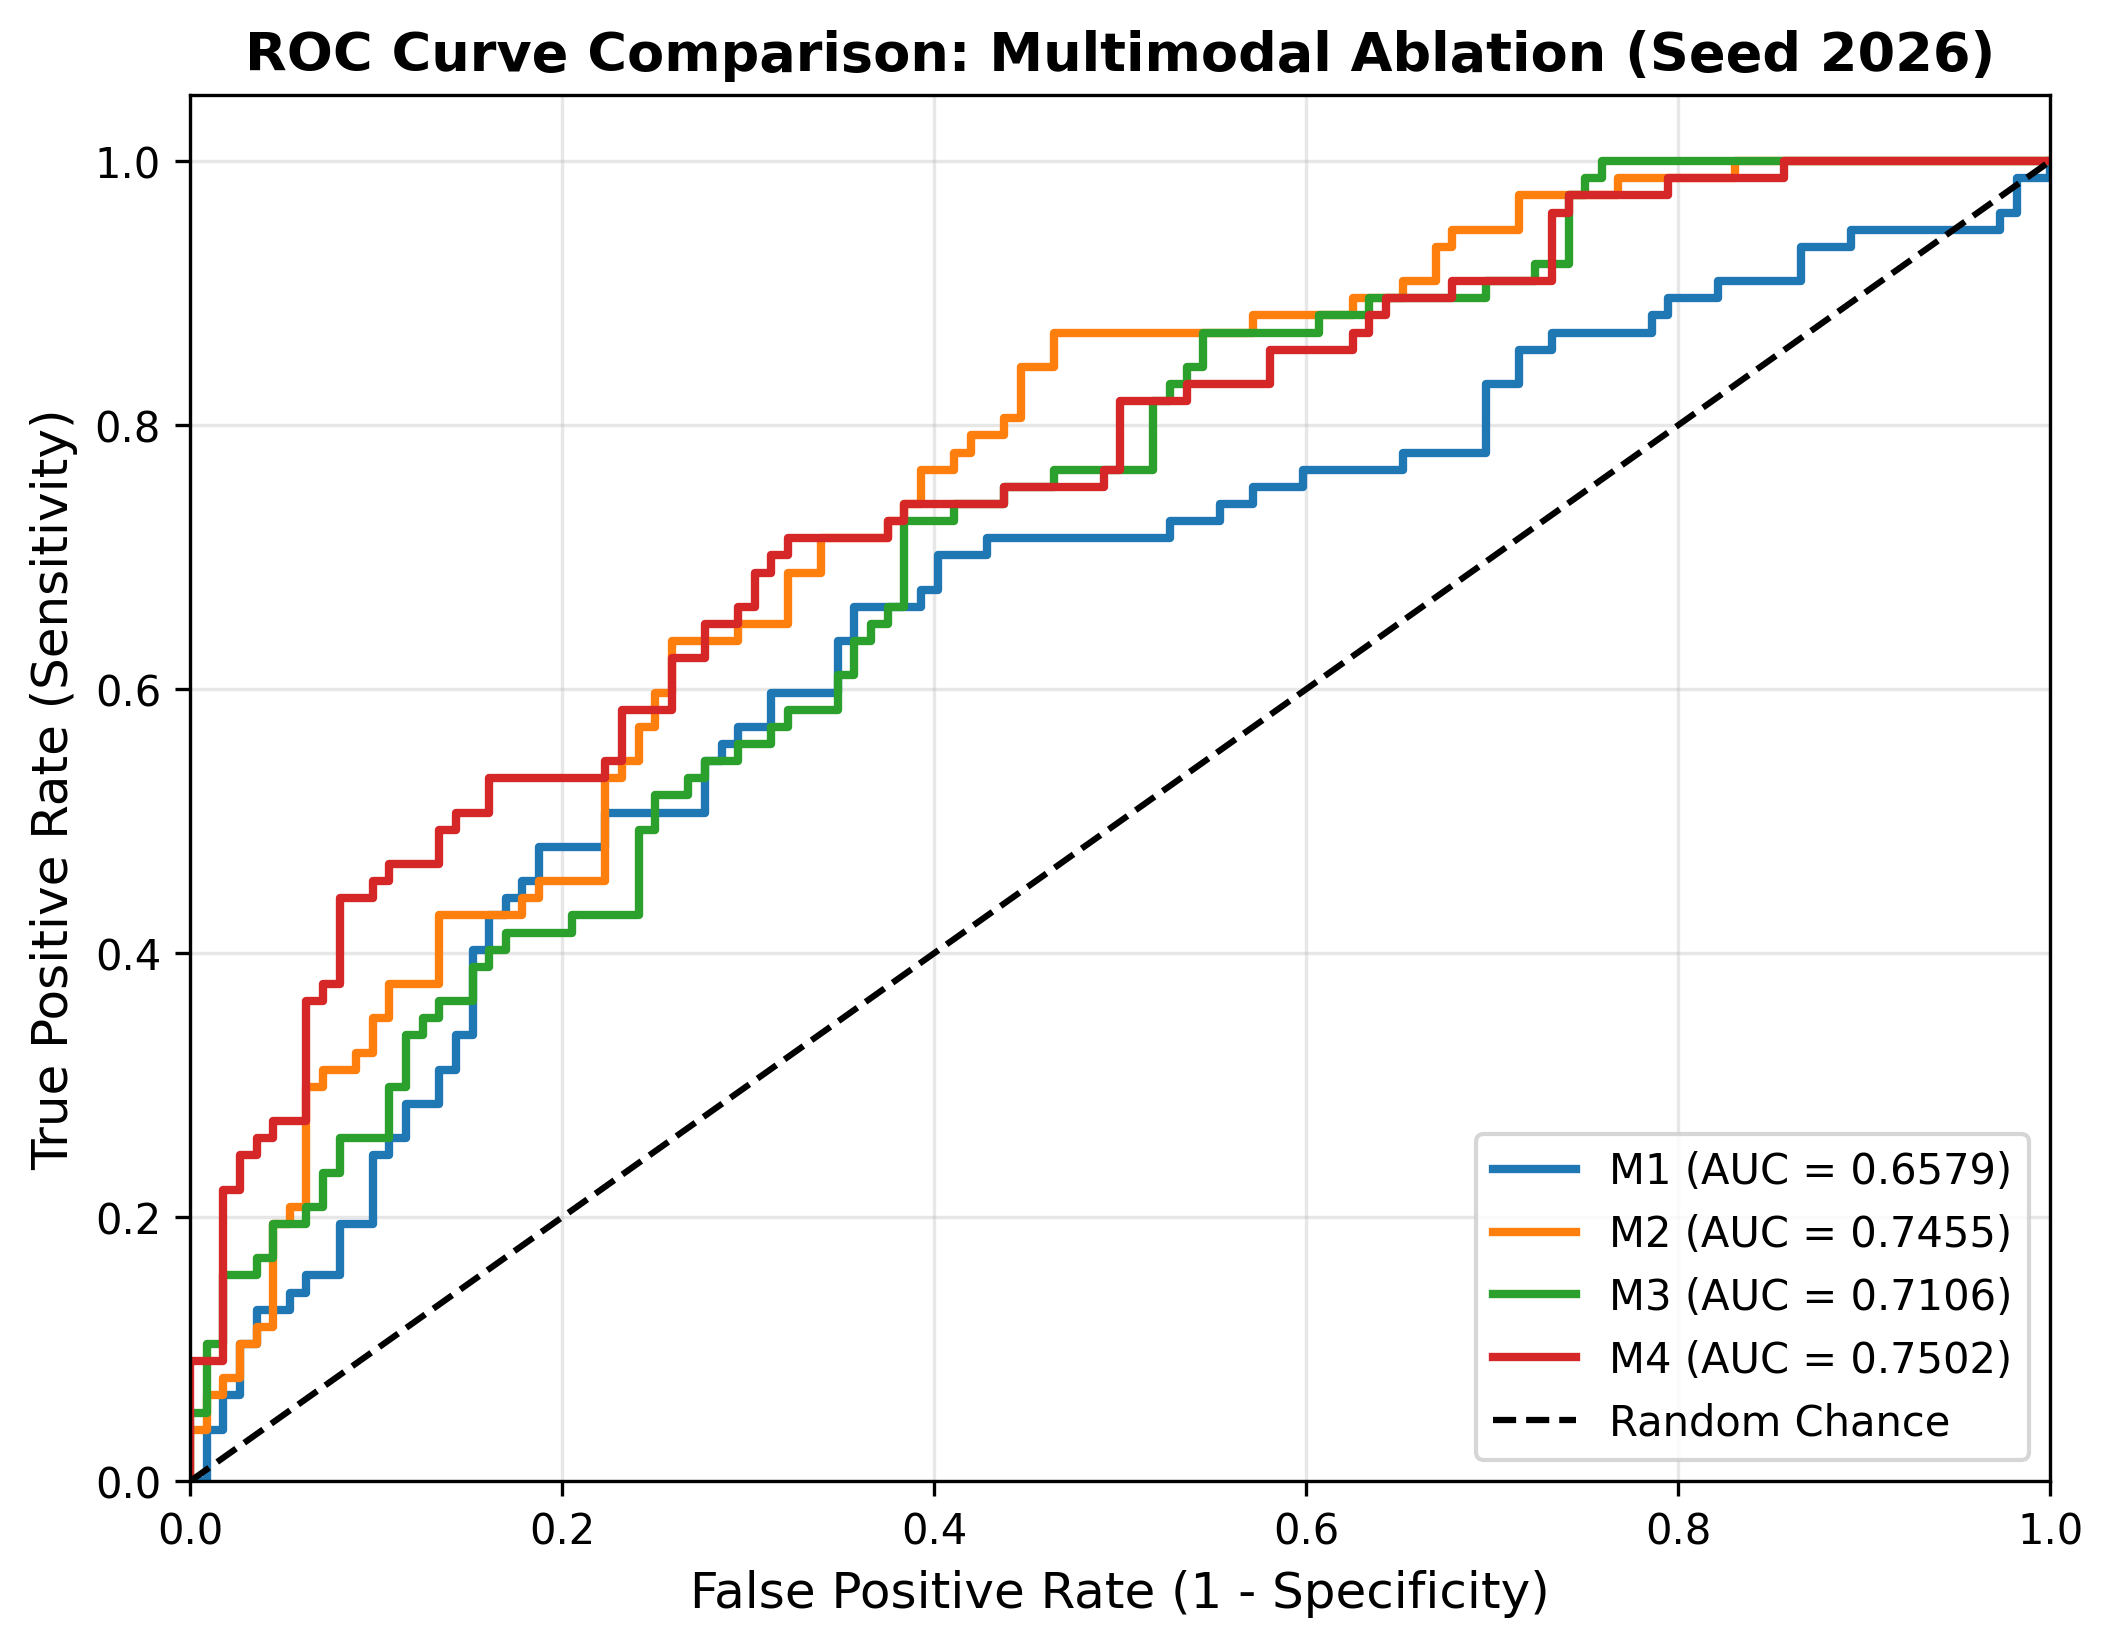

ROC curves saved to: CBISDDSM_Preprocessed_v2/reports/refined_roc_curves_m1_m4.png


In [ ]:
def find_optimal_threshold(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    """Finds the classification operating threshold maximizing Youden's J statistic."""
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    return float(thresholds[best_idx])

def eval_model(
    model: models.Model, 
    ds: tf.data.Dataset, 
    optimal_thresh: float = 0.5
) -> Tuple[Dict[str, float], np.ndarray, np.ndarray]:
    """Evaluates model predictions, computing standard (0.5) and threshold metrics."""
    y_true_list = []
    for batch in ds:
        y_true_list.append(batch[1].numpy())
    y_true = np.concatenate(y_true_list, axis=0)
    y_pred = model.predict(ds, verbose=0).flatten()
    
    auc = roc_auc_score(y_true, y_pred)
    
    # Standard threshold 0.5
    bin_05 = (y_pred >= 0.5).astype(int)
    sens_05 = recall_score(y_true, bin_05, zero_division=0)
    spec_05 = recall_score(1 - y_true, 1 - bin_05, zero_division=0)
    f1_05 = f1_score(y_true, bin_05, zero_division=0)
    
    # Clinical threshold
    bin_opt = (y_pred >= optimal_thresh).astype(int)
    sens_opt = recall_score(y_true, bin_opt, zero_division=0)
    spec_opt = recall_score(1 - y_true, 1 - bin_opt, zero_division=0)
    f1_opt = f1_score(y_true, bin_opt, zero_division=0)
    
    brier = brier_score_loss(y_true, y_pred)
    
    metrics = {
        'AUC': auc,
        'Sensitivity_05': sens_05, 'Specificity_05': spec_05, 'F1_05': f1_05,
        'Optimal_Threshold': optimal_thresh,
        'Sensitivity_Opt': sens_opt, 'Specificity_Opt': spec_opt, 'F1_Opt': f1_opt,
        'Brier': brier
    }
    return metrics, y_true, y_pred

def train_two_stage_model(
    model: models.Model,
    backbone: models.Model,
    ds_train: tf.data.Dataset,
    ds_val: tf.data.Dataset,
    class_weights: Dict[int, float],
    stage1_epochs: int = CFG.stage1_epochs,
    stage2_epochs: int = CFG.stage2_epochs,
    stage1_lr: float = CFG.stage1_lr,
    stage2_lr: float = CFG.stage2_lr
) -> None:
    """Train classification head with frozen backbone, then fine-tune backbone."""
    # Stage 1: Warm up head with frozen backbone
    model.compile(
        optimizer=optimizers.Adam(stage1_lr),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )
    model.fit(
        ds_train, validation_data=ds_val, epochs=stage1_epochs, class_weight=class_weights,
        callbacks=[callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True)],
        verbose=1
    )
    
    # Stage 2: Fine tune backbone while keeping BatchNormalization layers frozen
    backbone.trainable = True
    for layer in backbone.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
            
    model.compile(
        optimizer=optimizers.Adam(stage2_lr),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )
    model.fit(
        ds_train, validation_data=ds_val, epochs=stage2_epochs, class_weight=class_weights,
        callbacks=[
            callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True),
            callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3, mode='max', min_lr=1e-7)
        ],
        verbose=1
    )

seed_results: List[Dict[str, Any]] = []
models_last_seed: Dict[str, models.Model] = {}
predictions_last_seed: Dict[str, np.ndarray] = {}
final_seed_manifest: Optional[pd.DataFrame] = None
y_test_ground_truth: Optional[np.ndarray] = None

for seed_idx, seed in enumerate(CFG.seeds):
    print(f"\n--- Running Seed {seed} ({seed_idx + 1}/{len(CFG.seeds)}) ---")
    # Clear GPU session between seed runs to avoid memory fragmentation
    tf.keras.backend.clear_session()
    gc.collect()
    set_seed(seed)
    
    # 1. Stratified split and TDA standardization for this seed
    master_base = get_master_df_for_seed(seed, proc_df)
    master_s = scale_tda_for_seed(master_base, tda_normalized_df)
    
    # 2. Balanced class weights
    train_df = master_s[master_s.split == 'train']
    n_total = len(train_df)
    n_pos = train_df.label.sum()
    n_neg = n_total - n_pos
    class_weights = {0: float(n_total / (2.0 * n_neg)), 1: float(n_total / (2.0 * n_pos))}
    print(f"Class distribution: Benign={n_neg}, Malignant={n_pos} | Weights: {class_weights}")
    
    # 3. Build datasets
    ds_tr_img = create_dataset(master_s[master_s.split == 'train'], training=True, seed=seed, is_multimodal=False)
    ds_va_img = create_dataset(master_s[master_s.split == 'val'], training=False, seed=seed, is_multimodal=False)
    ds_te_img = create_dataset(master_s[master_s.split == 'test'], training=False, seed=seed, is_multimodal=False)
    
    ds_tr_m3 = create_dataset(master_s[master_s.split == 'train'], training=True, seed=seed, is_multimodal=True, null_tda=False)
    ds_va_m3 = create_dataset(master_s[master_s.split == 'val'], training=False, seed=seed, is_multimodal=True, null_tda=False)
    ds_te_m3 = create_dataset(master_s[master_s.split == 'test'], training=False, seed=seed, is_multimodal=True, null_tda=False)
    
    ds_tr_m4 = create_dataset(master_s[master_s.split == 'train'], training=True, seed=seed, is_multimodal=True, null_tda=True)
    ds_va_m4 = create_dataset(master_s[master_s.split == 'val'], training=False, seed=seed, is_multimodal=True, null_tda=True)
    ds_te_m4 = create_dataset(master_s[master_s.split == 'test'], training=False, seed=seed, is_multimodal=True, null_tda=True)
    
    # Validation ground truth for immediate permodel threshold tuning
    y_va_true = master_s[master_s.split == 'val'].label.values
    is_final_seed = (seed == CFG.seeds[-1])
    
    # --- Train & Evaluate M1: From Scratch CNN ---
    print("\n--- Training M1 (Custom CNN) ---")
    m1 = build_m1()
    m1.compile(optimizer=optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='auc')])
    m1.fit(
        ds_tr_img, validation_data=ds_va_img, epochs=50, class_weight=class_weights,
        callbacks=[callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True)],
        verbose=1
    )
    t_opt_m1 = find_optimal_threshold(y_va_true, m1.predict(ds_va_img, verbose=0).flatten())
    m1_met, y_t, m1_p = eval_model(m1, ds_te_img, optimal_thresh=t_opt_m1)
    y_test_ground_truth = y_t
    del m1
    tf.keras.backend.clear_session()
    gc.collect()
    
    # --- Train & Evaluate M2: EfficientNetB0 Baseline ---
    print("\n--- Training M2 (EfficientNetB0) ---")
    m2, m2_base = build_m2()
    train_two_stage_model(m2, m2_base, ds_tr_img, ds_va_img, class_weights)
    t_opt_m2 = find_optimal_threshold(y_va_true, m2.predict(ds_va_img, verbose=0).flatten())
    m2_met, _, m2_p = eval_model(m2, ds_te_img, optimal_thresh=t_opt_m2)
    if is_final_seed:
        models_last_seed['M2'] = m2
    else:
        del m2, m2_base
        tf.keras.backend.clear_session()
        gc.collect()
    
    # --- Train & Evaluate M3: Multimodal TDA Fusion ---
    print("\n--- Training M3 (Multimodal TDA Fusion) ---")
    m3, m3_base = build_fusion_model(name="M3_TDA_Fusion")
    train_two_stage_model(m3, m3_base, ds_tr_m3, ds_va_m3, class_weights)
    t_opt_m3 = find_optimal_threshold(y_va_true, m3.predict(ds_va_m3, verbose=0).flatten())
    m3_met, _, m3_p = eval_model(m3, ds_te_m3, optimal_thresh=t_opt_m3)
    if is_final_seed:
        models_last_seed['M3'] = m3
    else:
        del m3, m3_base
        tf.keras.backend.clear_session()
        gc.collect()
    
    # --- Train & Evaluate M4: Null Input Control ---
    print("\n--- Training M4 (Null-Input Control) ---")
    m4, m4_base = build_fusion_model(name="M4_NullControl")
    train_two_stage_model(m4, m4_base, ds_tr_m4, ds_va_m4, class_weights)
    t_opt_m4 = find_optimal_threshold(y_va_true, m4.predict(ds_va_m4, verbose=0).flatten())
    m4_met, _, m4_p = eval_model(m4, ds_te_m4, optimal_thresh=t_opt_m4)
    del m4, m4_base
    tf.keras.backend.clear_session()
    gc.collect()
    
    if is_final_seed:
        predictions_last_seed = {'M1': m1_p, 'M2': m2_p, 'M3': m3_p, 'M4': m4_p}
        final_seed_manifest = master_s.copy()
    
    for mod_name, met in [('M1_CNN', m1_met), ('M2_EfficientNet', m2_met), ('M3_Fusion', m3_met), ('M4_NullControl', m4_met)]:
        seed_results.append({'seed': seed, 'model': mod_name} | met)
        
    print(f"Seed {seed} Test Results:")
    print(f"  M1 (CNN)           AUC: {m1_met['AUC']:.4f} | Sens@Opt: {m1_met['Sensitivity_Opt']:.4f} | Spec@Opt: {m1_met['Specificity_Opt']:.4f} (Thresh={m1_met['Optimal_Threshold']:.3f})")
    print(f"  M2 (EfficientNet)  AUC: {m2_met['AUC']:.4f} | Sens@Opt: {m2_met['Sensitivity_Opt']:.4f} | Spec@Opt: {m2_met['Specificity_Opt']:.4f} (Thresh={m2_met['Optimal_Threshold']:.3f})")
    print(f"  M3 (TDA Fusion)    AUC: {m3_met['AUC']:.4f} | Sens@Opt: {m3_met['Sensitivity_Opt']:.4f} | Spec@Opt: {m3_met['Specificity_Opt']:.4f} (Thresh={m3_met['Optimal_Threshold']:.3f})")
    print(f"  M4 (Null Control)  AUC: {m4_met['AUC']:.4f} | Sens@Opt: {m4_met['Sensitivity_Opt']:.4f} | Spec@Opt: {m4_met['Specificity_Opt']:.4f} (Thresh={m4_met['Optimal_Threshold']:.3f})")

# Summary Performance Table Across Seeds
results_df = pd.DataFrame(seed_results)
report_dir = CFG.output_root / 'reports'
report_dir.mkdir(parents=True, exist_ok=True)
results_df.to_csv(report_dir / 'refined_individual_seed_metrics.csv', index=False)

summary = results_df.groupby('model').agg({
    'AUC': ['mean', 'std'],
    'Sensitivity_Opt': ['mean', 'std'],
    'Specificity_Opt': ['mean', 'std'],
    'F1_Opt': ['mean', 'std']
}).reset_index()

print("\n" + "="*80)
print(f"MULTI-SEED PERFORMANCE SUMMARY (Mean ± Std over Seeds: {CFG.seeds})")
print("="*80)
for _, r in summary.iterrows():
    m = r['model'].values[0] if isinstance(r['model'], pd.Series) else r['model']
    auc_m, auc_s = r[('AUC', 'mean')], r[('AUC', 'std')]
    sen_m, sen_s = r[('Sensitivity_Opt', 'mean')], r[('Sensitivity_Opt', 'std')]
    spe_m, spe_s = r[('Specificity_Opt', 'mean')], r[('Specificity_Opt', 'std')]
    f1_m,  f1_s  = r[('F1_Opt', 'mean')], r[('F1_Opt', 'std')]
    print(f"{m:<20} | AUC: {auc_m:.4f} ± {auc_s:.4f} | Sens@Opt: {sen_m:.4f} ± {sen_s:.4f} | Spec@Opt: {spe_m:.4f} ± {spe_s:.4f} | F1: {f1_m:.4f} ± {f1_s:.4f}")

# ROC Curve Plot
plt.figure(figsize=(8, 6), dpi=300)
colors = {'M1': '#1f77b4', 'M2': '#ff7f0e', 'M3': '#2ca02c', 'M4': '#d62728'}
for name in ['M1', 'M2', 'M3', 'M4']:
    fpr, tpr, _ = roc_curve(y_test_ground_truth, predictions_last_seed[name])
    score = roc_auc_score(y_test_ground_truth, predictions_last_seed[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {score:.4f})", color=colors[name], lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title(f'ROC Curve Comparison: Multimodal Ablation (Seed {CFG.seeds[-1]})', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', frameon=True)
plt.grid(alpha=0.3)
roc_path = report_dir / 'refined_roc_curves_m1_m4.png'
plt.savefig(roc_path, bbox_inches='tight')
plt.show()
print(f"ROC curves saved to: {roc_path}")


### Stage 6: Statistical Significance Testing: DeLong Non-Parametric AUC Comparison

In [ ]:
def delong_roc_variance(ground_truth: np.ndarray, predictions: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute DeLong's covariance matrix for correlated ROC curves.
    
    Theoretical reference: DeLong et al. (Biometrics 1988).
    Algorithmic formulation: Vectorized pairwise placement values mathematically equivalent to
    Sun & Xu (IEEE SPL 2014) but utilizing a naive O(m*n) complexity.
    
    Args:
        ground_truth: 1D array of true binary labels (0 or 1), length N.
        predictions: 2D array of model predicted probabilities of shape (k_models, N).
    Returns:
        aucs: 1D array of Mann-Whitney AUCs for each model, length k_models.
        delong_cov: 2D covariance matrix of shape (k_models, k_models).
    """
    ground_truth = np.asarray(ground_truth).ravel()
    predictions = np.atleast_2d(predictions)
    
    pos = (ground_truth == 1)
    neg = (ground_truth == 0)
    m = int(np.sum(pos))
    n = int(np.sum(neg))
    k = predictions.shape[0]
    
    if m == 0 or n == 0:
        raise ValueError("Ground truth must contain both positive and negative cases.")
        
    v10 = np.zeros((k, m), dtype=np.float64)
    v01 = np.zeros((k, n), dtype=np.float64)
    
    for i in range(k):
        x = predictions[i, pos]  # Positive class scores (m,)
        y = predictions[i, neg]  # Negative class scores (n,)
        # Pairwise comparison kernel
        diff = x[:, None] - y[None, :]
        comp = (diff > 0).astype(np.float64) + 0.5 * (diff == 0).astype(np.float64)
        # V10: Placement values for positive cases: mean over negative samples
        v10[i, :] = np.mean(comp, axis=1)
        # V01: Placement values for negative cases.
        v01[i, :] = 1.0 - np.mean(comp, axis=0)
        
    aucs = np.mean(v10, axis=1)
    s10 = np.cov(v10, ddof=1) if m > 1 else np.zeros((k, k))
    s01 = np.cov(v01, ddof=1) if n > 1 else np.zeros((k, k))
    
    delong_cov = (s10 / m) + (s01 / n)
    if k == 1:
        delong_cov = np.atleast_2d(delong_cov)
    return aucs, delong_cov

def compare_auc_delong(y_true: np.ndarray, pred_a: np.ndarray, pred_b: np.ndarray) -> Dict[str, float]:
    """Calculates the difference in AUC between two models, standard error, z-score, and p-value."""
    preds = np.vstack([pred_a, pred_b])
    aucs, cov = delong_roc_variance(y_true, preds)
    diff = aucs[0] - aucs[1]
    sigma2 = float(cov[0, 0] + cov[1, 1] - 2.0 * cov[0, 1])
    denom = np.sqrt(max(1e-12, sigma2))
    z = diff / denom
    p_value = scipy.stats.norm.sf(abs(z)) * 2.0
    return {
        'AUC_A': float(aucs[0]), 'AUC_B': float(aucs[1]),
        'Difference': float(diff), 'Z_Score': float(z),
        'P_Value': float(p_value)
    }

print("="*75)
print(f"STATISTICAL SIGNIFICANCE TESTING: DELONG TEST (Seed {CFG.seeds[-1]} Test Cohort)")
print("="*75)

comparisons = [
    ("M3_Fusion vs. M2_EfficientNet (Topological Added Value)", predictions_last_seed['M3'], predictions_last_seed['M2']),
    ("M3_Fusion vs. M4_NullControl  (True TDA vs Head Capacity)", predictions_last_seed['M3'], predictions_last_seed['M4']),
    ("M4_NullControl vs. M2_EfficientNet (Head Capacity Effect)",  predictions_last_seed['M4'], predictions_last_seed['M2'])
]

delong_records = []
for label, p_a, p_b in comparisons:
    res = compare_auc_delong(y_test_ground_truth, p_a, p_b)
    delong_records.append({'Comparison': label} | res)
    sig = ("*** (p<0.001)" if res['P_Value'] < 0.001
        else "** (p<0.01)" if res['P_Value'] < 0.01
        else "* (p<0.05)" if res['P_Value'] < 0.05
        else "(Not Significant)")
    print(f"{label}:")
    print(f"  AUC Difference: {res['Difference']:+.4f} | z = {res['Z_Score']:.3f} | p = {res['P_Value']:.4f} {sig}\n")

delong_df = pd.DataFrame(delong_records)
delong_path = report_dir / 'refined_delong_statistical_tests.csv'
delong_df.to_csv(delong_path, index=False)
print(f"DeLong statistical results saved to: {delong_path}")


STATISTICAL SIGNIFICANCE TESTING: DELONG TEST (Seed 2026 Test Cohort)
M3_Fusion vs. M2_EfficientNet (Topological Added Value):
  AUC Difference: -0.0349 | z = -1.491 | p = 0.1358 (Not Significant)

M3_Fusion vs. M4_NullControl  (True TDA vs Head Capacity):
  AUC Difference: -0.0397 | z = -1.697 | p = 0.0897 (Not Significant)

M4_NullControl vs. M2_EfficientNet (Head Capacity Effect):
  AUC Difference: +0.0048 | z = 0.245 | p = 0.8061 (Not Significant)

DeLong statistical results saved to: CBISDDSM_Preprocessed_v2/reports/refined_delong_statistical_tests.csv


### Stage 7: Model Interpretability: Grad-CAM Localization and Quantitative mIoU Evaluation


Computing quantitative directional Grad-CAM localization scores for M2, M4, and M3...

DIRECTIONAL QUANTITATIVE LOCALIZATION: MEAN IoU (mIoU ± Std)

--- ALL TEST LESIONS ---
Thresh 0.2   | M2 (EffNet): 0.3134 | M4 (Null Head): 0.2574 | M3 (TDA Fusion): 0.2207 | TDA Gain (M3-M4): -0.0367 | Head Eff (M4-M2): -0.0560
Thresh 0.4   | M2 (EffNet): 0.1917 | M4 (Null Head): 0.1377 | M3 (TDA Fusion): 0.1134 | TDA Gain (M3-M4): -0.0244 | Head Eff (M4-M2): -0.0540
Thresh 0.6   | M2 (EffNet): 0.0947 | M4 (Null Head): 0.0654 | M3 (TDA Fusion): 0.0534 | TDA Gain (M3-M4): -0.0120 | Head Eff (M4-M2): -0.0293
Thresh p75   | M2 (EffNet): 0.3190 | M4 (Null Head): 0.3264 | M3 (TDA Fusion): 0.3023 | TDA Gain (M3-M4): -0.0241 | Head Eff (M4-M2): +0.0074

--- MALIGNANT ONLY ---
Thresh 0.2   | M2 (EffNet): 0.2560 | M4 (Null Head): 0.3437 | M3 (TDA Fusion): 0.2533 | TDA Gain (M3-M4): -0.0904 | Head Eff (M4-M2): +0.0877
Thresh 0.4   | M2 (EffNet): 0.1471 | M4 (Null Head): 0.1796 | M3 (TDA Fusion): 0.1345 | TDA 

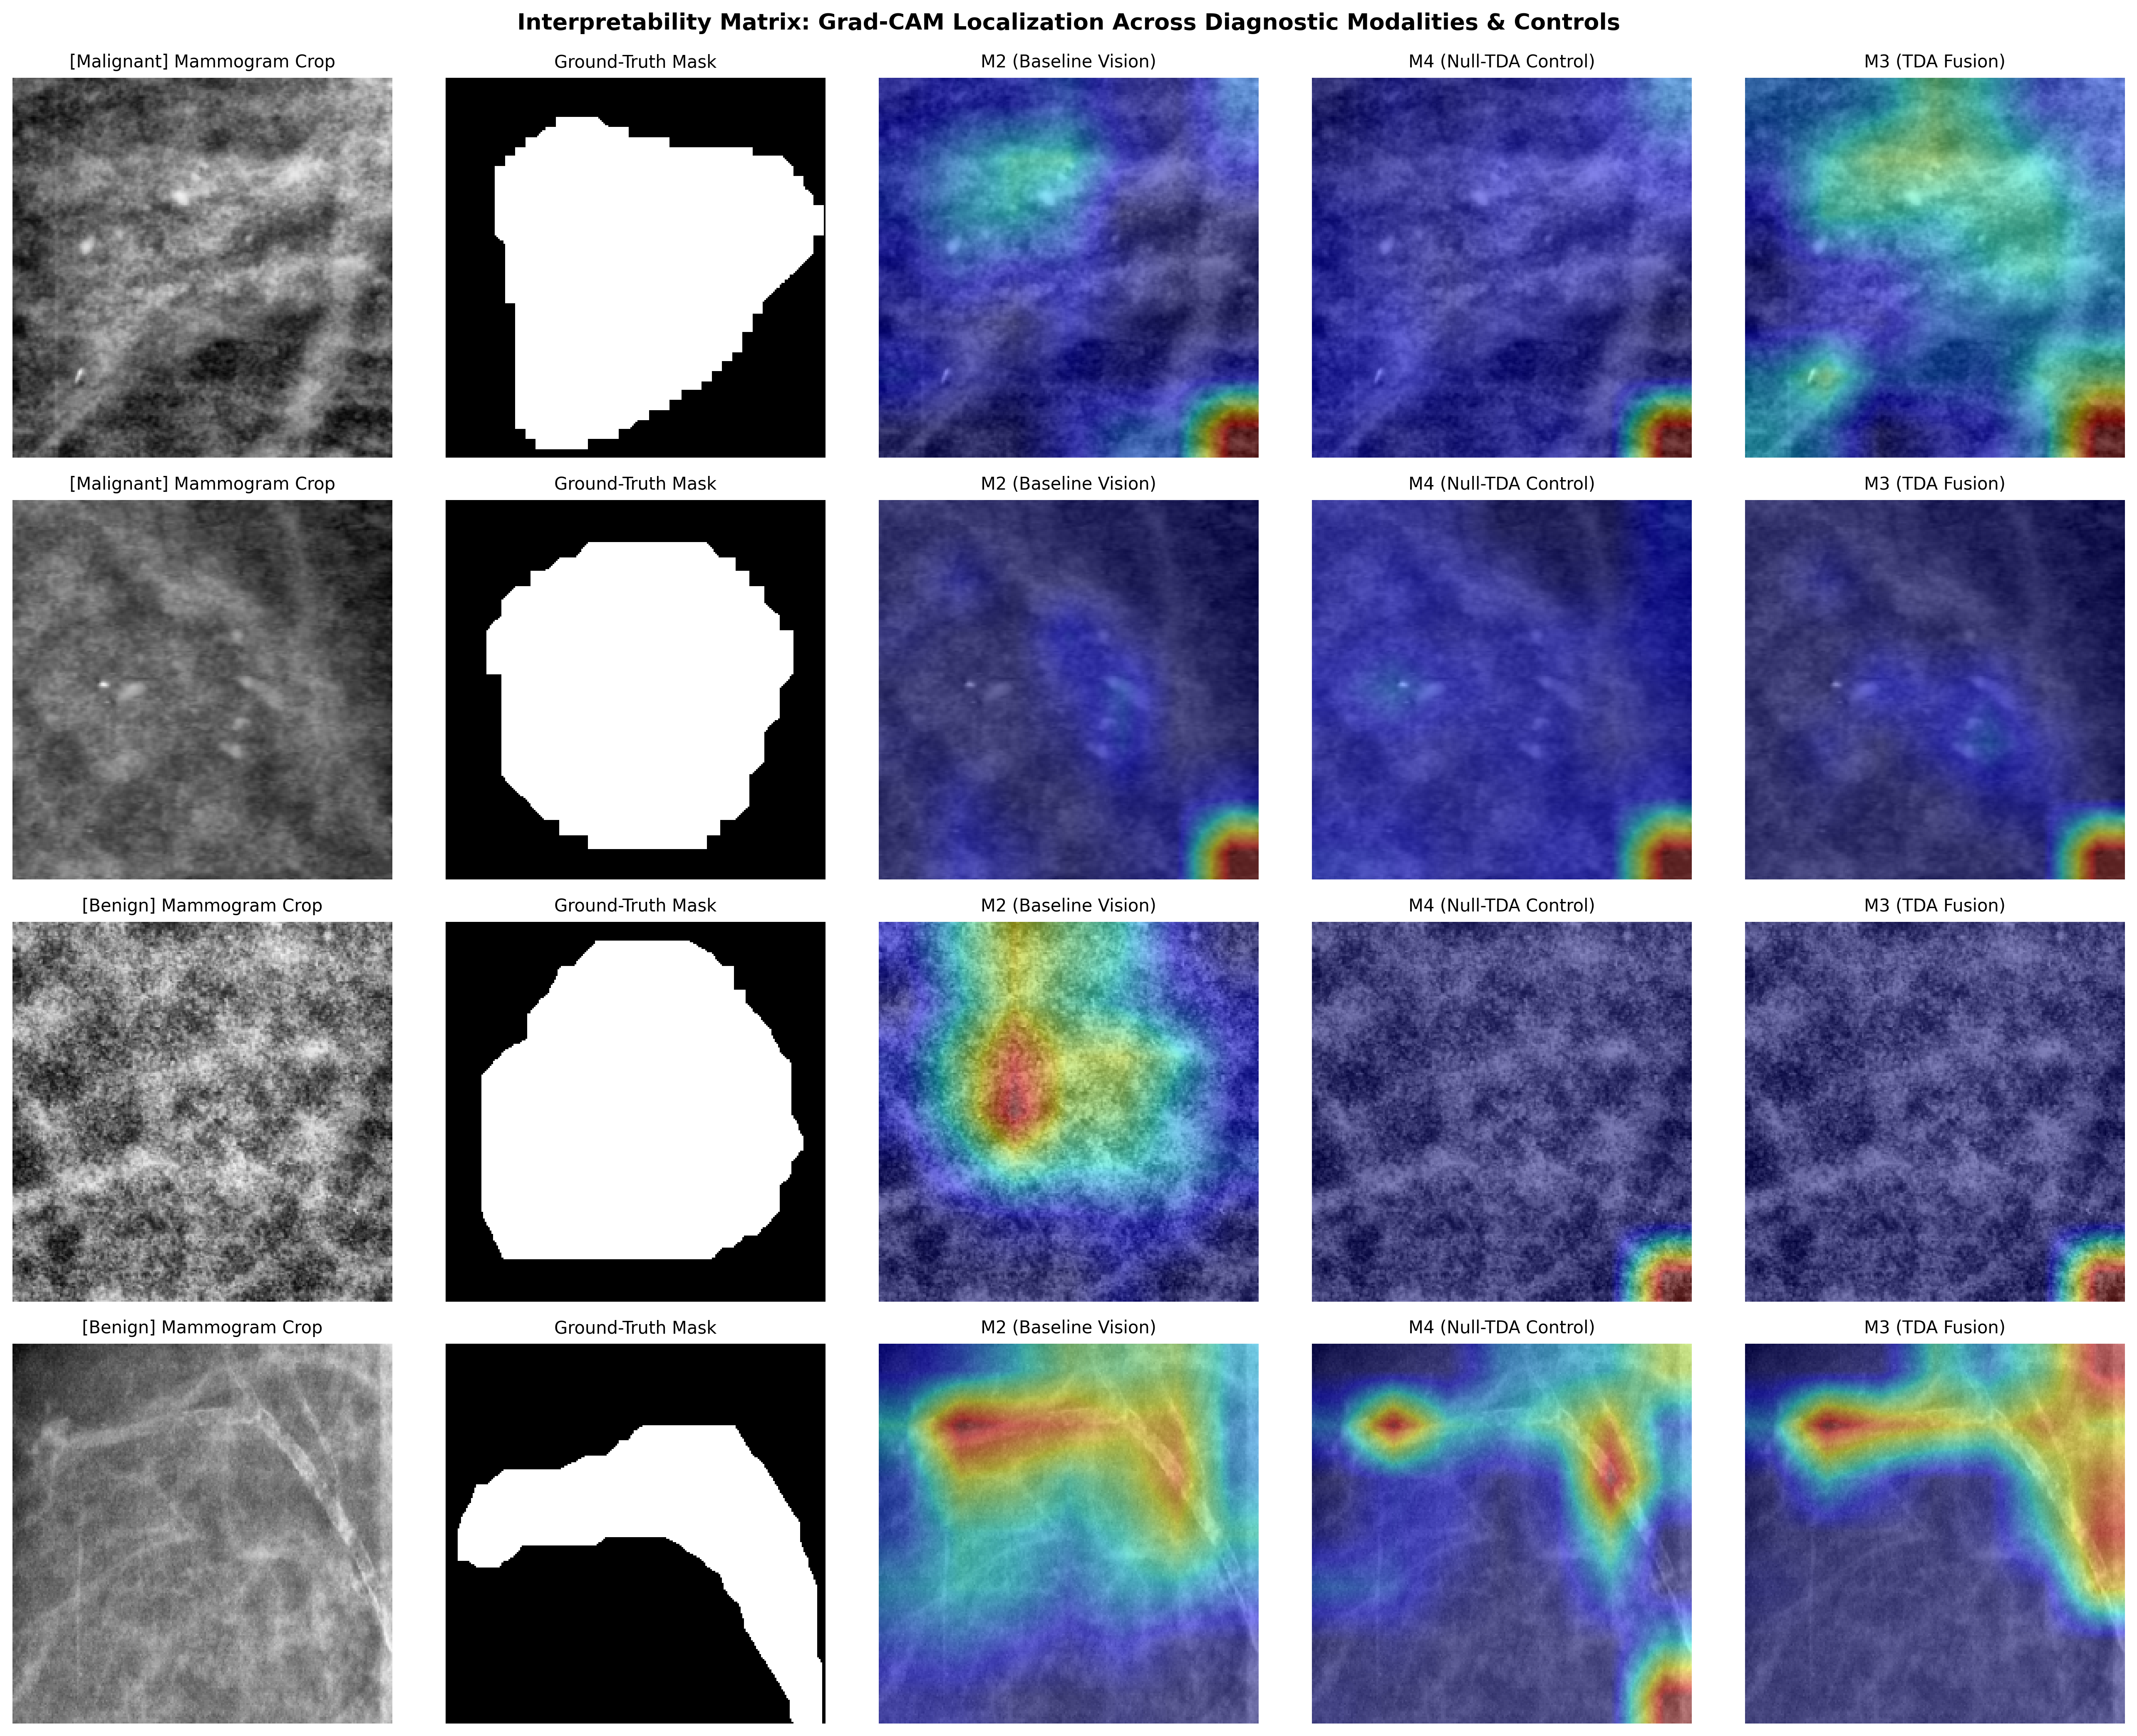

Interpretability Matrix figure saved to: CBISDDSM_Preprocessed_v2/reports/refined_gradcam_interpretability_matrix.png
All evaluations, statistical tests, and figures generated.


In [ ]:
def make_gradcam_heatmap(
    img_array: np.ndarray, 
    model: models.Model, 
    tda_vector: Optional[np.ndarray] = None,
    is_malignant: bool = True,
    last_conv_layer_name: str = 'top_activation'
) -> np.ndarray:
    """
    Generate class conditioned Grad-CAM activation heatmap for vision or multimodal models.
    Uses presigmoid linear logits to prevent gradient saturation (Selvaraju et al., 2017).
    """
    eff_submodel = model.get_layer('efficientnetb0')
    conv_layer = eff_submodel.get_layer(last_conv_layer_name)
    conv_extractor = models.Model(inputs=eff_submodel.input, outputs=conv_layer.output)
    dense_layer = model.get_layer('malignancy_prob')
    
    is_multimodal = (tda_vector is not None)
    
    with tf.GradientTape() as tape:
        conv_outputs = conv_extractor(img_array)
        tape.watch(conv_outputs)
        # mathematically identical to EfficientNetB0's internal GlobalAveragePooling2D
        gap = tf.reduce_mean(conv_outputs, axis=[1, 2])
        
        if is_multimodal:
            # Set training=False explicitly for BatchNormalization layers during inference
            vis_norm = model.get_layer('vision_bn')(gap, training=False)
            tda_norm = model.get_layer('tda_bn')(tda_vector, training=False)
            fused = model.get_layer('feature_fusion')([vis_norm, tda_norm])
            x = model.get_layer('fusion_dense_1')(fused)
            # Route through dropout in inference mode
            x = model.get_layer('fusion_dropout')(x, training=False)
            logit = tf.matmul(x, dense_layer.kernel) + dense_layer.bias
        else:
            # Route through M2 dropout layer in inference mode
            dropout_layers = [l for l in model.layers if isinstance(l, layers.Dropout)]
            gap_drop = dropout_layers[0](gap, training=False) if dropout_layers else gap
            logit = tf.matmul(gap_drop, dense_layer.kernel) + dense_layer.bias
            
        class_score = logit[:, 0] if is_malignant else -logit[:, 0]

    grads = tape.gradient(class_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0.0)
    denom = tf.math.reduce_max(heatmap)
    if denom > 0:
        heatmap = heatmap / denom
    return heatmap.numpy()

def compute_iou(heatmap: np.ndarray, gt_mask: np.ndarray, threshold: float = 0.5) -> float:
    """Compute Intersection over Union (Jaccard Index) between binarized saliency and ground truth mask."""
    if gt_mask.shape != heatmap.shape:
        gt_mask = cv2.resize(gt_mask, (heatmap.shape[1], heatmap.shape[0]), interpolation=cv2.INTER_NEAREST)
        
    cam_binary = (heatmap >= threshold).astype(bool)
    gt_binary = (gt_mask > 0).astype(bool)
    
    intersection = np.logical_and(cam_binary, gt_binary).sum()
    union = np.logical_or(cam_binary, gt_binary).sum()
    if union == 0:
        return np.nan
    return float(intersection / union)

# Evaluate Interpretability on Test Cohort
test_samples = final_seed_manifest[final_seed_manifest.split == 'test'].reset_index(drop=True)
m2_model = models_last_seed['M2']
m3_model = models_last_seed['M3']
m4_model = models_last_seed['M4']

iou_thresholds = [0.2, 0.4, 0.6, 'p75']
iou_records = []

target_hw = (CFG.image_height, CFG.image_width)
target_wh = (CFG.image_width, CFG.image_height)

print("Computing quantitative directional Grad-CAM localization scores for M2, M4, and M3.")
for idx, row in test_samples.iterrows():
    img_bgr = cv2.imread(str(row.image_png))
    mask_gray = cv2.imread(str(row.mask_png), cv2.IMREAD_GRAYSCALE)
    if img_bgr is None or mask_gray is None:
        continue
    if mask_gray.shape != target_hw:
        mask_gray = cv2.resize(mask_gray, target_wh, interpolation=cv2.INTER_NEAREST)
    
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    img_tensor = np.expand_dims(img_rgb, axis=0)
    
    tda_vec = np.expand_dims(row[[f'tda_{j}' for j in range(CFG.tda_dim)]].values.astype(np.float32), axis=0)
    tda_null = np.zeros_like(tda_vec)  # Null topological vector for M4 control
    
    is_mal = (row.label == 1)
    cam_m2 = make_gradcam_heatmap(img_tensor, m2_model, is_malignant=is_mal)
    cam_m4 = make_gradcam_heatmap(img_tensor, m4_model, tda_vector=tda_null, is_malignant=is_mal)
    cam_m3 = make_gradcam_heatmap(img_tensor, m3_model, tda_vector=tda_vec, is_malignant=is_mal)
    
    cam_m2_resized = cv2.resize(cam_m2, target_wh)
    cam_m4_resized = cv2.resize(cam_m4, target_wh)
    cam_m3_resized = cv2.resize(cam_m3, target_wh)
    
    for th in iou_thresholds:
        t_val_m2 = float(np.percentile(cam_m2_resized, 75)) if th == 'p75' else float(th)
        t_val_m4 = float(np.percentile(cam_m4_resized, 75)) if th == 'p75' else float(th)
        t_val_m3 = float(np.percentile(cam_m3_resized, 75)) if th == 'p75' else float(th)
        
        iou_m2 = compute_iou(cam_m2_resized, mask_gray, threshold=t_val_m2)
        iou_m4 = compute_iou(cam_m4_resized, mask_gray, threshold=t_val_m4)
        iou_m3 = compute_iou(cam_m3_resized, mask_gray, threshold=t_val_m3)
        
        iou_records.append({
            'sample_uid': row.sample_uid, 'label': row.label,
            'threshold': str(th), 
            'IoU_M2': iou_m2, 
            'IoU_M4': iou_m4, 
            'IoU_M3': iou_m3,
            'TDA_Gain_M3_vs_M4': iou_m3 - iou_m4,   # Pure topological signal effect
            'Head_Effect_M4_vs_M2': iou_m4 - iou_m2 # Pure head capacity effect
        })

iou_df = pd.DataFrame(iou_records)
iou_df = iou_df.dropna(subset=['IoU_M2', 'IoU_M4', 'IoU_M3'])

print("\n" + "="*95)
print("DIRECTIONAL QUANTITATIVE LOCALIZATION: MEAN IoU (mIoU ± Std)")
print("="*95)
for lbl_name, l_val in [('ALL TEST LESIONS', None), ('MALIGNANT ONLY', 1), ('BENIGN ONLY', 0)]:
    sub_df = iou_df if l_val is None else iou_df[iou_df.label == l_val]
    summary_sub = sub_df.groupby('threshold').agg({
        'IoU_M2': ['mean', 'std'], 
        'IoU_M4': ['mean', 'std'], 
        'IoU_M3': ['mean', 'std'],
        'TDA_Gain_M3_vs_M4': ['mean', 'std'],
        'Head_Effect_M4_vs_M2': ['mean', 'std']
    }).reset_index()
    print(f"\n--- {lbl_name} ---")
    for _, r in summary_sub.iterrows():
        th = r['threshold'].values[0] if isinstance(r['threshold'], pd.Series) else r['threshold']
        m2_m, m2_s = r[('IoU_M2', 'mean')], r[('IoU_M2', 'std')]
        m4_m, m4_s = r[('IoU_M4', 'mean')], r[('IoU_M4', 'std')]
        m3_m, m3_s = r[('IoU_M3', 'mean')], r[('IoU_M3', 'std')]
        tda_gain   = r[('TDA_Gain_M3_vs_M4', 'mean')]
        head_eff   = r[('Head_Effect_M4_vs_M2', 'mean')]
        print(f"Thresh {th:<5} | M2 (EffNet): {m2_m:.4f} | M4 (Null Head): {m4_m:.4f} | M3 (TDA Fusion): {m3_m:.4f} | TDA Gain (M3-M4): {tda_gain:+.4f} | Head Eff (M4-M2): {head_eff:+.4f}")

iou_path = report_dir / 'refined_gradcam_iou_quantitative_summary.csv'
iou_df.to_csv(iou_path, index=False)
print(f"\nQuantitative IoU results saved to: {iou_path}")

# Interpretability Matrix Visualization
rep_samples = pd.concat([
    test_samples[test_samples.label == 1].head(2),
    test_samples[test_samples.label == 0].head(2)
])

fig, axes = plt.subplots(len(rep_samples), 5, figsize=(17.5, 3.5 * len(rep_samples)), dpi=300)
for i, (_, row) in enumerate(rep_samples.iterrows()):
    img_bgr = cv2.imread(str(row.image_png))
    mask_gray = cv2.imread(str(row.mask_png), cv2.IMREAD_GRAYSCALE)
    if img_bgr is None or mask_gray is None:
        continue
    if mask_gray.shape != target_hw:
        mask_gray = cv2.resize(mask_gray, target_wh, interpolation=cv2.INTER_NEAREST)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    img_tensor = np.expand_dims(img_rgb, axis=0)
    tda_vec = np.expand_dims(row[[f'tda_{j}' for j in range(CFG.tda_dim)]].values.astype(np.float32), axis=0)
    tda_null = np.zeros_like(tda_vec)
    
    is_mal = (row.label == 1)
    cam_m2 = cv2.resize(make_gradcam_heatmap(img_tensor, m2_model, is_malignant=is_mal), target_wh)
    cam_m4 = cv2.resize(make_gradcam_heatmap(img_tensor, m4_model, tda_vector=tda_null, is_malignant=is_mal), target_wh)
    cam_m3 = cv2.resize(make_gradcam_heatmap(img_tensor, m3_model, tda_vector=tda_vec, is_malignant=is_mal), target_wh)
    
    lbl_text = "Malignant" if row.label == 1 else "Benign"
    
    # 1. Mammogram Crop
    axes[i, 0].imshow(np.uint8(img_rgb))
    axes[i, 0].set_title(f"[{lbl_text}] Mammogram Crop", fontsize=10)
    axes[i, 0].axis('off')
    
    # 2. Ground Truth Mask
    axes[i, 1].imshow(mask_gray, cmap='gray')
    axes[i, 1].set_title("Ground-Truth Mask", fontsize=10)
    axes[i, 1].axis('off')
    
    # 3. M2 Grad-CAM
    axes[i, 2].imshow(np.uint8(img_rgb))
    axes[i, 2].imshow(cam_m2, cmap='jet', alpha=0.45)
    axes[i, 2].set_title("M2 (Baseline Vision)", fontsize=10)
    axes[i, 2].axis('off')
    
    # 4. M4 Grad-CAM 
    axes[i, 3].imshow(np.uint8(img_rgb))
    axes[i, 3].imshow(cam_m4, cmap='jet', alpha=0.45)
    axes[i, 3].set_title("M4 (Null-TDA Control)", fontsize=10)
    axes[i, 3].axis('off')

    # 5. M3 Grad-CAM 
    axes[i, 4].imshow(np.uint8(img_rgb))
    axes[i, 4].imshow(cam_m3, cmap='jet', alpha=0.45)
    axes[i, 4].set_title("M3 (TDA Fusion)", fontsize=10)
    axes[i, 4].axis('off')

plt.suptitle("Interpretability Matrix: Grad-CAM Localization Across Diagnostic Modalities & Controls", fontsize=13, fontweight='bold', y=0.99)
plt.tight_layout()
matrix_path = report_dir / 'refined_gradcam_interpretability_matrix.png'
plt.savefig(matrix_path, bbox_inches='tight')
plt.show()
print(f"Interpretability Matrix figure saved to: {matrix_path}")
print("All evaluations, statistical tests, and figures generated.")
